In [19]:
"""Dataset validation — replay correctness & ML readiness"""

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

DATASET_PATH = "../dataset.parquet"

# Load data + metadata
pf = pq.read_table(DATASET_PATH)
df = pf.to_pandas()
meta = {k.decode(): v.decode() for k, v in pf.schema.metadata.items() if not k.startswith(b"pandas") and not k.startswith(b"ARROW")}
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

print("=== Parquet metadata ===")
for k, v in sorted(meta.items()):
    print(f"  {k}: {v}")
print(f"\nShape: {df.shape}")
print(f"Time span: {df.datetime.min()} — {df.datetime.max()}")
print(f"Duration: {df.datetime.max() - df.datetime.min()}")

=== Parquet metadata ===
  data_path: data/raw/binance/BTCUSDT
  horizon_ms: 200
  interval_ms: 100
  rows: 747336
  sequence_gaps: 6
  step_size: 0.00001
  symbol: BTCUSDT
  tick_size: 0.01
  trade_window_ms: 1000
  warmup_s: 600

Shape: (747336, 11)
Time span: 2026-03-14 20:12:00.200000 — 2026-03-15 19:24:09
Duration: 0 days 23:12:08.800000


In [22]:
df[600000:].head(20)

,timestamp,spread,imbalance_1,imbalance_5,imbalance_10,microprice_minus_mid,delta_midprice,buy_volume,sell_volume,label,datetime
600000,1773587915500,0.01,0.648251,0.652705,0.666561,0.003241,0.0,0.00124,0.00000,0.0,2026-03-15 15:18:35.500
600001,1773587915600,0.01,0.649074,0.653504,0.667295,0.003245,0.0,0.00124,0.00084,0.0,2026-03-15 15:18:35.600
600002,1773587915700,0.01,0.608912,0.614597,0.631769,0.003045,0.0,0.00124,0.00786,0.0,2026-03-15 15:18:35.700
600003,1773587915800,0.01,0.608912,0.614563,0.508800,0.003045,0.0,0.00124,0.00786,0.0,2026-03-15 15:18:35.800
600004,1773587915900,0.01,0.608912,0.614563,0.631739,0.003045,0.0,0.00093,0.00786,0.0,2026-03-15 15:18:35.900
600005,1773587916000,0.01,0.608912,0.614563,0.631739,0.003045,0.0,0.00093,0.00786,0.0,2026-03-15 15:18:36.000
600006,1773587916100,0.01,0.608865,0.614518,0.631697,0.003044,0.0,0.00072,0.00812,0.0,2026-03-15 15:18:36.100
600007,1773587916200,0.01,0.608865,0.614518,0.631697,0.003044,0.0,0.00072,0.00812,0.0,2026-03-15 15:18:36.200
600008,1773587916300,0.01,0.608865,0.614518,0.631697,0.003044,0.0,0.00072,0.00812,0.0,2026-03-15 15:18:36.300
600009,1773587916400,0.01,0.607639,0.613329,0.507418,0.003038,0.0,0.00072,0.00812,0.0,2026-03-15 15:18:36.400


In [23]:
# --- 1. Timestamp integrity ---

interval_ms = int(meta.get("interval_ms", 50))

ts_diff = df["timestamp"].diff().dropna()
expected = ts_diff == interval_ms
non_grid = ts_diff[~expected]

print("=== Timestamp validation ===")
print(f"Expected interval: {interval_ms}ms")
print(f"Total rows: {len(df):,}")
print(f"On-grid: {expected.sum():,} ({expected.mean():.2%})")
print(f"Off-grid: {len(non_grid):,}")
print(f"Strictly increasing: {(ts_diff > 0).all()}")
print(f"Nulls: {df.isnull().any().any()}")

if len(non_grid) > 0:
    print(f"\nOff-grid interval distribution:")
    print(non_grid.describe())

    # Show where gaps occur (timestamps that jump more than 2x interval)
    big_gaps = ts_diff[ts_diff > interval_ms * 2]
    if len(big_gaps) > 0:
        print(f"\nLarge gaps (>{interval_ms*2}ms): {len(big_gaps)}")
        gap_times = df.loc[big_gaps.index, "datetime"]
        gap_sizes = big_gaps / 1000  # to seconds
        for t, s in zip(gap_times.head(10), gap_sizes.head(10)):
            print(f"  {t}  gap={s:.1f}s")

=== Timestamp validation ===
Expected interval: 100ms
Total rows: 747,336
On-grid: 747,333 (100.00%)
Off-grid: 2
Strictly increasing: True
Nulls: False

Off-grid interval distribution:
count    2.000000e+00
mean     4.397750e+06
std      5.300543e+06
min      6.497000e+05
25%      2.523725e+06
50%      4.397750e+06
75%      6.271775e+06
max      8.145800e+06
Name: timestamp, dtype: float64

Large gaps (>200ms): 2
  2026-03-14 22:48:09.700000  gap=8145.8s
  2026-03-15 08:54:08.200000  gap=649.7s


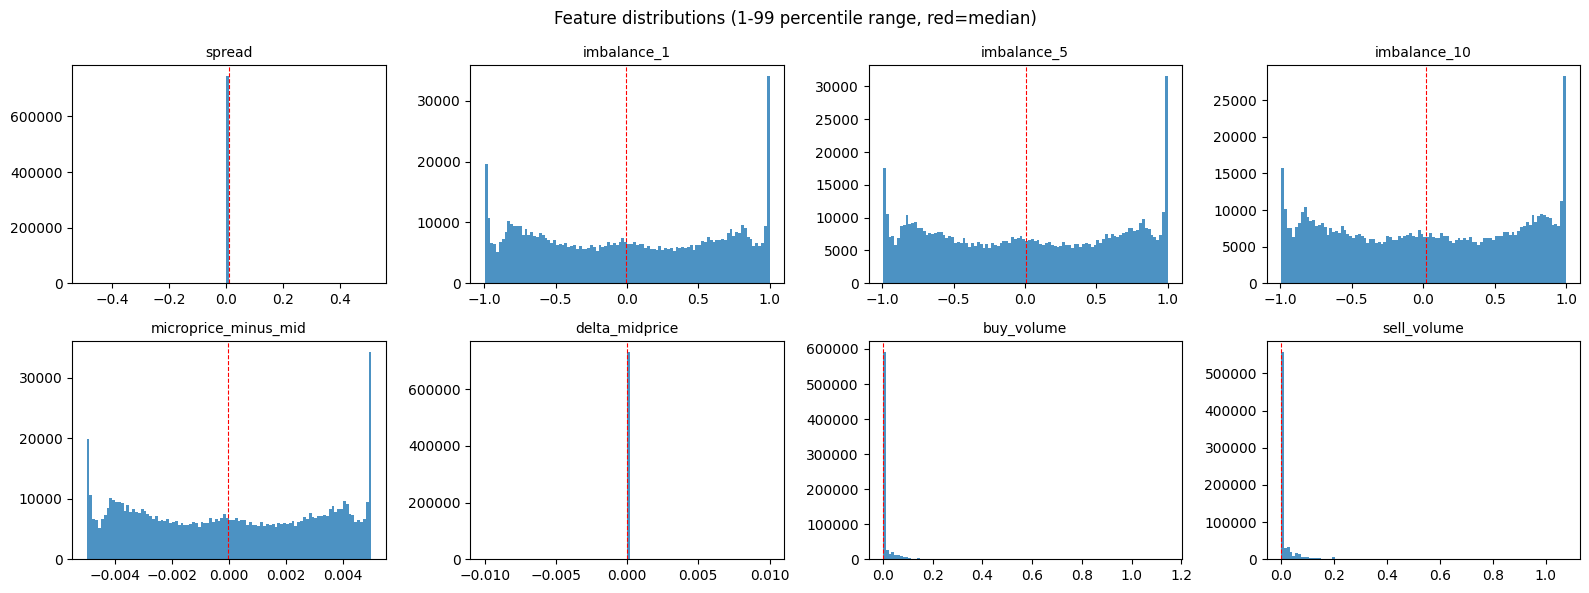

=== Feature stats ===
            spread  imbalance_1  imbalance_5  imbalance_10  microprice_minus_mid  delta_midprice   buy_volume  sell_volume
count  747336.0000  747336.0000  747336.0000   747336.0000           747336.0000     747336.0000  747336.0000  747336.0000
mean        0.0117       0.0057       0.0131        0.0214                0.0001          0.0010       0.0808       0.0757
std         0.1032       0.6391       0.6389        0.6368                0.0417          0.8859       1.1510       0.9979
min         0.0100      -1.0000      -0.9999       -0.9998               -8.0135        -87.1150       0.0000       0.0000
25%         0.0100      -0.5904      -0.5819       -0.5681               -0.0030          0.0000       0.0000       0.0000
50%         0.0100      -0.0057       0.0055        0.0198               -0.0000          0.0000       0.0003       0.0004
75%         0.0100       0.6015       0.6111        0.6195                0.0030          0.0000       0.0056       0

In [24]:
# --- 2. Feature distributions ---

features = ["spread", "imbalance_1", "imbalance_5", "imbalance_10",
            "microprice_minus_mid", "delta_midprice", "buy_volume", "sell_volume"]

left_quantile, right_quantile = 0.01, 0.99

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, features):
    data = df[col]
    lo, hi = data.quantile(left_quantile), data.quantile(right_quantile)
    ax.hist(data, bins=100, range=(lo, hi), edgecolor="none", alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.axvline(data.median(), color="red", ls="--", linewidth=0.8)
fig.suptitle(f"Feature distributions ({left_quantile * 100:.0f}-{right_quantile * 100:.0f} percentile range, red=median)", fontsize=12)
fig.tight_layout()
plt.show()

print("=== Feature stats ===")
print(df[features].describe().round(4).to_string())

In [ ]:
# --- 3. Label analysis ---

label = df["label"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution (clipped)
ax = axes[0]
lo, hi = label.quantile(0.005), label.quantile(0.995)
ax.hist(label, bins=200, range=(lo, hi), edgecolor="none", alpha=0.8)
ax.set_title("Label distribution (0.5-99.5 pctl)")
ax.set_xlabel("midprice change (USDT)")
ax.axvline(0, color="red", ls="--", linewidth=0.8)

# Zero vs nonzero breakdown
ax = axes[1]
zero_pct = (label == 0).mean()
pos_pct = (label > 0).mean()
neg_pct = (label < 0).mean()
ax.bar(["zero", "positive", "negative"], [zero_pct, pos_pct, neg_pct],
       color=["gray", "green", "red"], alpha=0.7)
ax.set_ylabel("fraction")
ax.set_title(f"Label balance (zero={zero_pct:.1%})")

# Label over time
ax = axes[2]
rolling = df.set_index("datetime")["label"].resample("5min")
ax.plot(rolling.mean().index, rolling.mean(), linewidth=0.8, label="mean")
ax.fill_between(rolling.std().index, -rolling.std(), rolling.std(),
                alpha=0.2, label="±std")
ax.set_title("Label mean & std over time (5min)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.tight_layout()
plt.show()

print(f"Label stats:")
print(f"  mean:   {label.mean():.6f}")
print(f"  std:    {label.std():.4f}")
print(f"  min:    {label.min():.2f}")
print(f"  max:    {label.max():.2f}")
print(f"  zero:   {zero_pct:.1%}")
print(f"  |label| > 1 tick ({float(meta.get('tick_size', 0.01))}): {(label.abs() > float(meta.get('tick_size', 0.01))).mean():.1%}")

In [ ]:
# --- 4. Replay gap boundaries ---
# Check that sequence gaps (warmup restarts) left clean boundaries in the dataset.

big_gaps = ts_diff[ts_diff > interval_ms * 2]
n_gaps = int(meta.get("sequence_gaps", 0))

print(f"=== Replay gaps ===")
print(f"Sequence gaps during replay: {n_gaps}")
print(f"Timestamp jumps > {interval_ms*2}ms in dataset: {len(big_gaps)}")
print(f"(These should match: each gap triggers warmup → timestamp jump)")

if len(big_gaps) > 0:
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(df["datetime"], ts_diff.reindex(df.index, fill_value=interval_ms),
            ".", markersize=0.5, alpha=0.3)
    for idx in big_gaps.index:
        ax.axvline(df.loc[idx, "datetime"], color="red", alpha=0.5, linewidth=0.8)
    ax.set_yscale("log")
    ax.set_ylabel("timestamp delta (ms)")
    ax.set_title(f"Timestamp deltas (red = gaps > {interval_ms*2}ms)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlabel("time (UTC)")
    fig.tight_layout()
    plt.show()

In [ ]:
# --- 5. Feature-label correlations & leakage check ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
ax = axes[0]
corr = df[features + ["label"]].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature-label correlation matrix")

# Feature-label bar
ax = axes[1]
feat_label_corr = corr["label"].drop("label").sort_values()
colors = ["green" if v > 0 else "red" for v in feat_label_corr]
ax.barh(feat_label_corr.index, feat_label_corr.values, color=colors, alpha=0.7)
ax.set_xlabel("Pearson correlation with label")
ax.set_title("Feature → label correlation")
ax.axvline(0, color="black", linewidth=0.5)

fig.tight_layout()
plt.show()

# Leakage check: label should NOT have high correlation with same-row features
# (features are causal — computed before label horizon)
print("=== Leakage check ===")
suspicious = feat_label_corr[feat_label_corr.abs() > 0.3]
if len(suspicious) > 0:
    print(f"WARNING: features with |corr| > 0.3 to label:")
    for name, val in suspicious.items():
        print(f"  {name}: {val:.3f}")
else:
    print("OK: no feature has |corr| > 0.3 with label (no obvious leakage)")

In [ ]:
# --- 6. Features over time (stationarity visual check) ---

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)

for ax, col in zip(axes.flat, features):
    resampled = df.set_index("datetime")[col].resample("5min")
    ax.plot(resampled.mean().index, resampled.mean(), linewidth=0.8)
    ax.fill_between(resampled.std().index,
                    resampled.mean() - resampled.std(),
                    resampled.mean() + resampled.std(), alpha=0.2)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("value")

axes[-1, -1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle("Feature mean ± std over time (5min bins)", fontsize=12)
fig.tight_layout()
plt.show()

In [ ]:
# --- 7. Outliers ---

print("=== Outliers (beyond 5 std from mean) ===")
for col in features + ["label"]:
    mean, std = df[col].mean(), df[col].std()
    outliers = ((df[col] - mean).abs() > 5 * std).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} ({outliers/len(df):.4%})")

print()
print("=== Constant or near-constant features ===")
for col in features:
    nunique = df[col].nunique()
    most_common_pct = df[col].value_counts(normalize=True).iloc[0]
    if most_common_pct > 0.9:
        print(f"  {col}: {most_common_pct:.1%} same value (nunique={nunique})")

In [ ]:
# --- 8. Summary verdict ---

issues = []

# Timestamp checks
if not (ts_diff > 0).all():
    issues.append("FAIL: timestamps not strictly increasing")
if len(big_gaps) == 0 and n_gaps > 0:
    issues.append("WARN: sequence gaps reported but no timestamp jumps in dataset")
if len(big_gaps) != n_gaps:
    issues.append(f"INFO: {len(big_gaps)} timestamp jumps vs {n_gaps} sequence gaps")

# Null check
if df.isnull().any().any():
    issues.append("FAIL: null values present")

# Label check
if zero_pct > 0.95:
    issues.append(f"WARN: {zero_pct:.0%} labels are zero — consider larger horizon")

# Leakage check
if len(suspicious) > 0:
    issues.append(f"WARN: possible leakage — {len(suspicious)} features with |corr| > 0.3 to label")

# Spread check
if (df["spread"] == 0).mean() > 0.5:
    issues.append("WARN: >50% spread=0 (locked book)")

print("=" * 50)
print("DATASET VALIDATION SUMMARY")
print("=" * 50)
if not issues:
    print("ALL CHECKS PASSED")
else:
    for issue in issues:
        print(f"  {issue}")
print()
print(f"Rows: {len(df):,}")
print(f"Features: {len(features)}")
print(f"Duration: {df.datetime.max() - df.datetime.min()}")
print(f"Label zero rate: {zero_pct:.1%}")
print(f"Sequence gaps: {n_gaps}")